In [33]:
import networkx as nx
import pandas as pd
import itertools

In [34]:
df = pd.read_csv("nodes.csv")
df2 = pd.read_csv("filtered_nodes.csv")

G = nx.Graph()

# get set of nodes that should be red
red_nodes = set(df2["name"])

for _, row in df.iterrows():
    node_name = row["name"]
    
    color = "red" if node_name in red_nodes else "blue"
    
    G.add_node(
        node_name,
        station=row["station"],
        lat=row["lat"],
        lng=row["lng"],
        color=color
    )

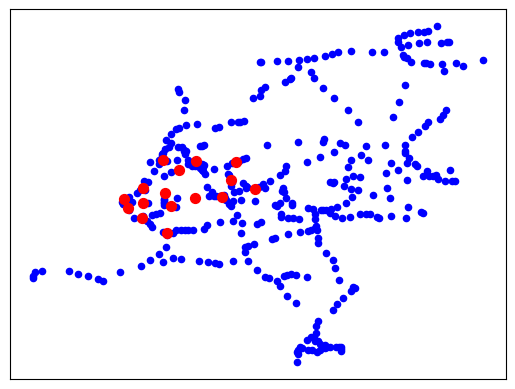

In [35]:
pos = {
    node: (data["lng"], data["lat"])
    for node, data in G.nodes(data=True)
}

red_nodes = [n for n in G.nodes() if G.nodes[n]["color"] == "red"]
blue_nodes = [n for n in G.nodes() if G.nodes[n]["color"] != "red"]

# draw blue first
nx.draw_networkx_nodes(
    G, pos,
    nodelist=blue_nodes,
    node_color="blue",
    node_size=20
)

# draw red on top
nx.draw_networkx_nodes(
    G, pos,
    nodelist=red_nodes,
    node_color="red",
    node_size=50
)

In [36]:
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # km

    lat1 = np.radians(lat1)
    lat2 = np.radians(lat2)
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)

    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return R * c

In [37]:
edges_df = pd.read_csv("edges.csv")

for _, row in edges_df.iterrows():
    n1 = row["from"]
    n2 = row["to"]

    lat1, lon1 = G.nodes[n1]["lat"], G.nodes[n1]["lng"]
    lat2, lon2 = G.nodes[n2]["lat"], G.nodes[n2]["lng"]

    dist = haversine(lat1, lon1, lat2, lon2)

    G.add_edge(n1, n2, weight=dist)

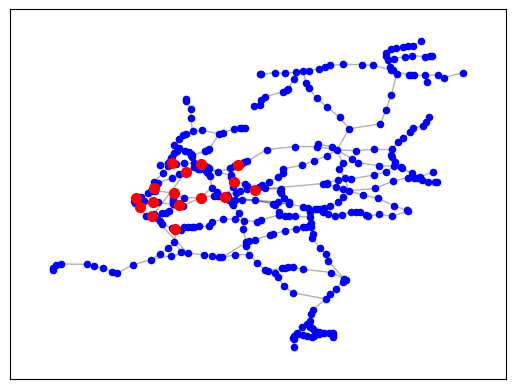

In [38]:
# edges
nx.draw_networkx_edges(G, pos, alpha=0.3)

# nodes (layered)
nx.draw_networkx_nodes(G, pos, nodelist=blue_nodes, node_color="blue", node_size=20)
nx.draw_networkx_nodes(G, pos, nodelist=red_nodes, node_color="red", node_size=50)

In [39]:
# all red cities
red_nodes = [n for n in G.nodes() if G.nodes[n]["color"] == "red"]

results = []

for source, target in itertools.combinations(red_nodes, 2):
    try:
        path = nx.shortest_path(G, source=source, target=target, weight="weight")
        distance = nx.shortest_path_length(G, source=source, target=target, weight="weight")

        results.append({
            "from": source,
            "to": target,
            "distance_km": distance,
            "path": path
        })
    except nx.NetworkXNoPath:
        results.append({
            "from": source,
            "to": target,
            "distance_km": None,
            "path": None
        })

shortest_paths_df = pd.DataFrame(results)

In [40]:
print(shortest_paths_df)

    from   to  distance_km                                               path
0    ALM  APN    43.053440  [ALM, ALMM, AMPO, NDB, BSMZ, HVSM, HVS, HVSP, ...
1    ALM  AMF    19.382959  [ALM, ALMM, AMPO, NDB, BSMZ, HVSM, HVS, BRN, AMF]
2    ALM  ASD    21.561287        [ALM, ALMM, AMPO, WP, DMN, ASSP, ASDM, ASD]
3    ALM   DT    58.697908  [ALM, ALMM, AMPO, WP, DMN, ASSP, ASDM, ASD, SH...
4    ALM  GVC    60.727389  [ALM, ALMM, AMPO, WP, DMN, ASSP, ASDM, ASD, AS...
..   ...  ...          ...                                                ...
115  SHL   WD    22.189984      [SHL, ASDZ, RAI, DVD, ASB, ASHD, AC, BKL, WD]
116  SHL  ZTM    40.189062  [SHL, HFD, NVP, SSH, LEDN, DVNK, VST, GVM, LAA...
117   UT   WD    14.794005                           [UT, UTZL, MAS, BKL, WD]
118   UT  ZTM    43.276381  [UT, UTZL, MAS, BKL, WD, GDG, GD, LLZM, ZTMO, ...
119   WD  ZTM    28.482377                     [WD, GDG, GD, LLZM, ZTMO, ZTM]

[120 rows x 4 columns]


In [41]:
red_set = set(red_nodes)

direct_connections = []

for _, row in shortest_paths_df.iterrows():
    path = row["path"]
    
    if path is None:
        continue

    # only check intermediate nodes, not start/end
    intermediate_nodes = path[1:-1]

    # keep only if all intermediate nodes are blue
    if all(node not in red_set for node in intermediate_nodes):
        direct_connections.append({
            "from": row["from"],
            "to": row["to"],
            "distance_km": row["distance_km"],
            "path": path
        })

red_city_connections_df = pd.DataFrame(direct_connections)



In [42]:
print(red_city_connections_df)

    from    to  distance_km                                               path
0    ALM   ASD    21.561287        [ALM, ALMM, AMPO, WP, DMN, ASSP, ASDM, ASD]
1    ALM   HVS     6.527708            [ALM, ALMM, AMPO, NDB, BSMZ, HVSM, HVS]
2    APN    GD     4.887712              [APN, BSK, BSKS, WADN, WAD, WADT, GD]
3    APN  LEDN    12.020389                                   [APN, LDL, LEDN]
4    APN    WD    16.112657                                     [APN, BDG, WD]
5    AMF   HVS    12.855251                                    [AMF, BRN, HVS]
6    AMF    UT    17.765756                           [AMF, DLD, BHV, UTO, UT]
7    ASD   HLM    17.777563                        [ASD, ASS, HWZB, HLMS, HLM]
8    ASD   HVS    19.150371   [ASD, ASDM, ASSP, DMN, WP, NDB, BSMZ, HVSM, HVS]
9    ASD   SHL     9.398063                                         [ASD, SHL]
10   ASD    UT    16.148262  [ASD, ASDM, ASA, DVD, ASB, ASHD, AC, BKL, MAS,...
11   ASD    WD    14.599860      [ASD, ASDM, ASA, DV

{'ALM': Text(5.21764, 52.37503, 'ALM'),
 'APN': Text(4.6577777862549, 52.124443054199, 'APN'),
 'AMF': Text(5.3705554008484, 52.153888702393, 'AMF'),
 'ASD': Text(4.9002776145935, 52.378887176514, 'ASD'),
 'DT': Text(4.3563890457153, 52.00666809082, 'DT'),
 'GVC': Text(4.3249998092651, 52.080276489258, 'GVC'),
 'DDR': Text(4.668333530426, 51.807220458984, 'DDR'),
 'GD': Text(4.7044444084167, 52.017501831055, 'GD'),
 'HLM': Text(4.6383333206177, 52.38777923584, 'HLM'),
 'HVS': Text(5.1819443702698, 52.225833892822, 'HVS'),
 'LEDN': Text(4.4816665649414, 52.166110992432, 'LEDN'),
 'RTD': Text(4.468888759613, 51.92499923706, 'RTD'),
 'SHL': Text(4.7619442939758, 52.30944442749, 'SHL'),
 'UT': Text(5.1102776527405, 52.088890075684, 'UT'),
 'WD': Text(4.8936109542847, 52.084999084473, 'WD'),
 'ZTM': Text(4.4772224426269, 52.047500610352, 'ZTM')}

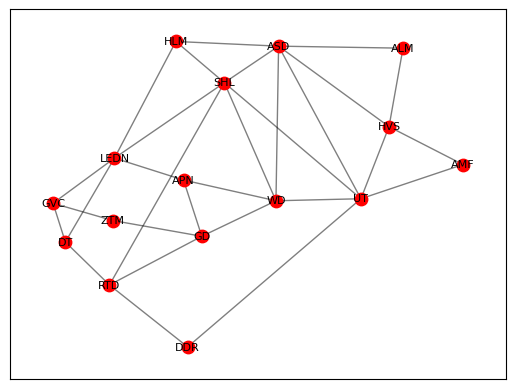

In [43]:
# create reduced graph with only red cities
G_red = nx.Graph()

# add red city nodes with original attributes
for node, data in G.nodes(data=True):
    if data.get("color") == "red":
        G_red.add_node(node, **data)

# add only the filtered red-red connections
for _, row in red_city_connections_df.iterrows():
    G_red.add_edge(
        row["from"],
        row["to"],
        weight=row["distance_km"]
    )

# positions from lat/lon
pos_red = {
    node: (data["lng"], data["lat"])
    for node, data in G_red.nodes(data=True)
}


nx.draw_networkx_edges(G_red, pos_red, alpha=0.5)
nx.draw_networkx_nodes(G_red, pos_red, node_color="red", node_size=80)
nx.draw_networkx_labels(G_red, pos_red, font_size=8)

In [ ]:
# =============================================================
# Network Metrics Table
# Computed on G_red (reduced graph of red/key-city nodes)
# Dyadicity computed on the full graph G (red vs blue nodes)
# =============================================================

# ------------------------------------------------------------------
# 1. Degree Centrality of Nodes (DCS)
#    Fraction of other nodes each node is connected to.
# ------------------------------------------------------------------
dcs = nx.degree_centrality(G_red)

# ------------------------------------------------------------------
# 2. Closeness Centrality of Nodes (CCN)
#    How close a node is to all others (uses edge weights as distances).
#    A larger weight means a longer path, so shorter distances => higher
#    centrality is preserved by passing distance='weight'.
# ------------------------------------------------------------------
ccn = nx.closeness_centrality(G_red, distance='weight')

# ------------------------------------------------------------------
# 3. Betweenness Centrality of Nodes (BCN)
#    Fraction of all-pairs shortest paths that pass through each node.
#    Normalised to [0, 1].
# ------------------------------------------------------------------
bcn = nx.betweenness_centrality(G_red, weight='weight', normalized=True)

# ------------------------------------------------------------------
# 4. Local Clustering Coefficient of Nodes (LCN)
#    Fraction of a node's neighbours that are also connected to each other.
#    Weighted variant accounts for edge strengths.
# ------------------------------------------------------------------
lcn = nx.clustering(G_red, weight='weight')

# ------------------------------------------------------------------
# 5. Dyadicity (graph-level scalar)
#    Ratio of observed same-type edges to the expected number in a random
#    graph with the same degree sequence.
#      D > 1  ->  assortative (same-type nodes connect more than by chance)
#      D < 1  ->  disassortative
#      D = 1  ->  random mixing
#    Computed on the full graph G where nodes are typed 'red' or 'blue'.
# ------------------------------------------------------------------
def compute_dyadicity(G, attribute='color'):
    """Return dyadicity for a graph whose nodes carry a categorical attribute."""
    nodes = list(G.nodes())
    n = len(nodes)
    m = G.number_of_edges()
    if n < 2 or m == 0:
        return None
    # count nodes per type
    type_counts = {}
    for node in nodes:
        t = G.nodes[node].get(attribute, 'unknown')
        type_counts[t] = type_counts.get(t, 0) + 1
    # actual same-type edges
    same_type_edges = sum(
        1 for u, v in G.edges()
        if G.nodes[u].get(attribute) == G.nodes[v].get(attribute)
    )
    # expected same-type edges under random graph with same n, m
    expected_same = m * sum(c * (c - 1) for c in type_counts.values()) / (n * (n - 1))
    return same_type_edges / expected_same if expected_same > 0 else None

dyadicity = compute_dyadicity(G, attribute='color')

# ------------------------------------------------------------------
# Build and display the combined metrics table
# ------------------------------------------------------------------
metrics_df = pd.DataFrame({
    'Node': list(G_red.nodes()),
    'Station': [G_red.nodes[n]['station'] for n in G_red.nodes()],
    'DCS':  [round(dcs[n],  4) for n in G_red.nodes()],
    'CCN':  [round(ccn[n],  4) for n in G_red.nodes()],
    'BCN':  [round(bcn[n],  4) for n in G_red.nodes()],
    'LCN':  [round(lcn[n],  4) for n in G_red.nodes()],
})

metrics_df = metrics_df.sort_values('DCS', ascending=False).reset_index(drop=True)

print("=" * 70)
print("NETWORK METRICS TABLE  (G_red — key-city subgraph)")
print("=" * 70)
print(metrics_df.to_string(index=False))
print()
print("Columns:")
print("  DCS  Degree Centrality          – fraction of nodes this node connects to")
print("  CCN  Closeness Centrality       – inverse avg. shortest weighted path length")
print("  BCN  Betweenness Centrality     – fraction of shortest paths through node")
print("  LCN  Local Clustering Coeff.   – fraction of neighbours that are mutually connected")
print()
print("-" * 70)
print(f"Dyadicity (full graph G, red vs blue):  {dyadicity:.4f}")
print("  D < 1 → fewer same-type edges than expected by chance (disassortative)")
print("  D = 1 → random mixing")
print("  D > 1 → more same-type edges than expected by chance (assortative)")
print("-" * 70)
